# RoPE — Rotary Positional Embeddings From Scratch

**The context:** `../nanogpt-from-scratch` used a *learned* positional embedding table — one
row per position. That capped context at `block_size` (see the note in `../kv-cache`) and
encoded *absolute* position when language mostly cares about *relative* position.

**RoPE** (Su et al. 2021 — used by Llama, Mistral, Qwen, DeepSeek, …) fixes both with one idea:
don't *add* a position vector — **rotate** each query and key by an angle proportional to its
position. The attention score then depends only on the **relative** distance, and since it's a
formula (not a table) it works at any length.

By the end you will:
- See the 2D-rotation intuition behind RoPE
- **Prove** the score q·k depends only on (j − i)
- Watch RoPE apply at position 100,000 with no lookup table (length extrapolation)


---
## 0 · The problem with adding positions

Learned/absolute schemes do `x = token_embedding + position_embedding`. That means:
- **Fixed length:** position 5000 has no row if you only trained to 1024.
- **Absolute, not relative:** the model sees "position 7" and "position 9" as unrelated
  vectors and must *learn* that what matters is that they're 2 apart.

We want a scheme where the interaction between token *i* and token *j* depends on **j − i**
directly, and that is defined for any position. That is exactly what a rotation gives you.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from rope import rope_tables, apply_rope, verify_relative_property, score_vs_distance

plt.rcParams.update({
    "figure.facecolor": "#0f1117", "axes.facecolor": "#1a1d27",
    "axes.edgecolor": "#2a2d3e", "axes.labelcolor": "#e2e8f0",
    "text.color": "#e2e8f0", "xtick.color": "#94a3b8", "ytick.color": "#94a3b8",
    "axes.titlecolor": "#e2e8f0", "grid.color": "#2a2d3e", "figure.dpi": 110,
})
print("ready")

ready


---
## 1 · The idea: position = rotation angle

Split a vector into 2D pairs. For a pair at position *p*, rotate it by angle *p·θ*, where
each pair has its own frequency *θ* (like `sin/cos` positional encoding, but applied as a
rotation to Q and K rather than added). Rotating query *q* at position *i* and key *k* at
position *j*, then taking their dot product, gives a value that depends only on the
**angle difference** (i − j)·θ — the relative position.

Below: take one 2D vector and rotate it by increasing position. That corkscrew *is* RoPE
acting on one dimension-pair.


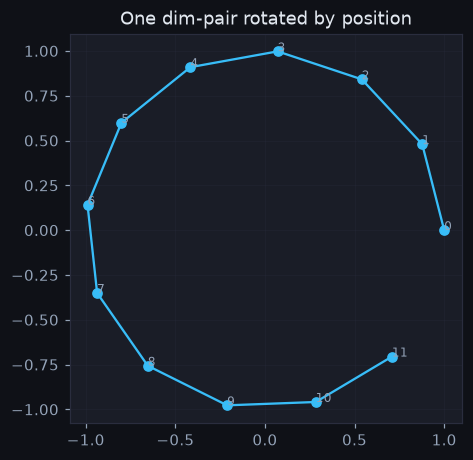

In [2]:
v = np.array([1.0, 0.0])
positions = np.arange(0, 12)
# one pair, one frequency: rotate v by p * theta
theta = 0.5
pts = np.array([[np.cos(p*theta)*v[0] - np.sin(p*theta)*v[1],
                 np.sin(p*theta)*v[0] + np.cos(p*theta)*v[1]] for p in positions])
fig, ax = plt.subplots(figsize=(4.4, 4.4))
ax.plot(pts[:,0], pts[:,1], "-o", color="#38bdf8")
for p,(x,y) in zip(positions, pts):
    ax.annotate(str(p), (x,y), color="#94a3b8", fontsize=8)
ax.set_title("One dim-pair rotated by position"); ax.set_aspect("equal"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

High-index dimension pairs use much lower frequencies (rotate slowly), low-index pairs
rotate fast — so together they encode position across many scales, like the binary digits
of a number. Here are the per-position angles for each pair:

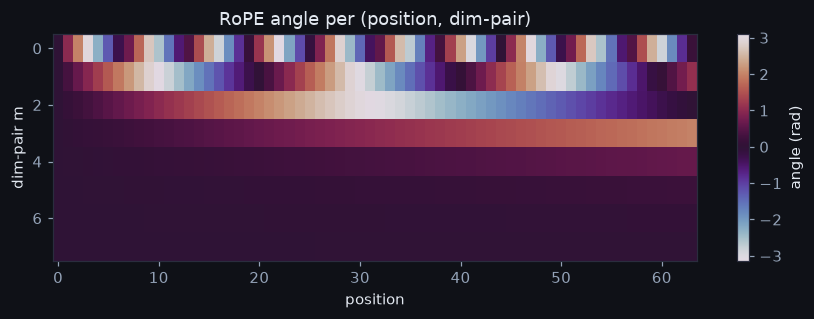

In [3]:
cos, sin = rope_tables(np.arange(64, dtype=float), dim=16)
fig, ax = plt.subplots(figsize=(8, 3.0))
im = ax.imshow(np.arctan2(sin, cos).T, aspect="auto", cmap="twilight")
ax.set(title="RoPE angle per (position, dim-pair)", xlabel="position", ylabel="dim-pair m")
fig.colorbar(im, ax=ax, label="angle (rad)"); plt.tight_layout(); plt.show()

---
## 2 · Prove it: the score depends only on (j − i)

The whole claim is that `<RoPE(q, i), RoPE(k, j)>` is a function of the offset only. We fix an
offset, slide the pair along many absolute positions, and confirm the dot product stays
constant. This is RoPE's correctness proof.


In [4]:
worst = verify_relative_property()
print(f"max spread of the score at a fixed offset (over 200 absolute positions): {worst:.2e}")
print("PASS — purely relative." if worst < 1e-9 else "FAIL")

max spread of the score at a fixed offset (over 200 absolute positions): 9.33e-15
PASS — purely relative.


---
## 3 · The score as a function of distance

For two fixed random vectors, plot the RoPE dot product as their separation grows. It's a
smooth, relative-distance-dependent signal injected straight into attention — and it keeps
going far past any table size.


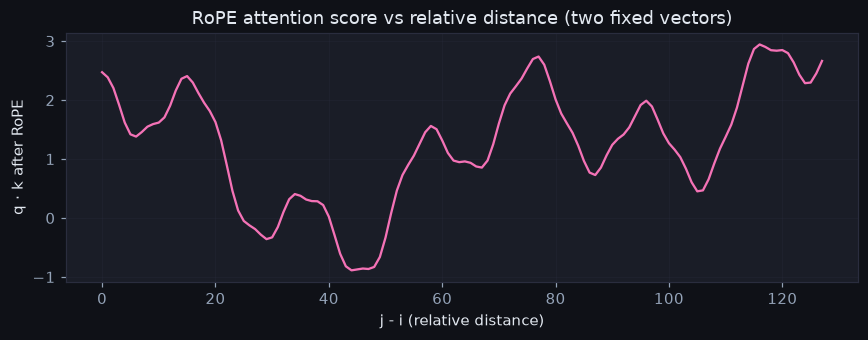

In [5]:
dists, scores = score_vs_distance(dim=16, max_dist=128)
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.plot(dists, scores, color="#f472b6")
ax.set(title="RoPE attention score vs relative distance (two fixed vectors)",
       xlabel="j - i (relative distance)", ylabel="q · k after RoPE")
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

---
## 4 · Length extrapolation: no table, any position

Learned positions die past `block_size`. RoPE is a formula, so position 100,000 is just...
another angle. This is why RoPE models can be context-extended (NTK / YaRN scaling all build
on this) where a lookup table simply cannot.


In [6]:
x = np.random.default_rng(1).standard_normal((3, 16))
out = apply_rope(x, np.array([0.0, 1024.0, 100000.0]))
print("applied RoPE at positions [0, 1024, 100000] — shapes:", out.shape)
print("no lookup table, no block_size cap.")

applied RoPE at positions [0, 1024, 100000] — shapes: (3, 16)
no lookup table, no block_size cap.


---
## 5 · Where it fits

- **Drop-in for our GPT:** replace the learned `pos_emb` add with `apply_rope` on Q and K
  inside `CausalSelfAttention`. Everything else (`../nanogpt-from-scratch`) is unchanged.
- **Plays well with the KV-cache:** you rotate K by its absolute position *before* caching,
  so cached keys are already position-encoded — RoPE and `../kv-cache` compose cleanly.
- **The real world:** Llama, Mistral, Qwen, DeepSeek and most current open models use RoPE;
  context-length tricks (Position Interpolation, NTK-aware, YaRN) are all RoPE rescalings.


---
## 6 · Summary

| Piece | Where | Job |
|---|---|---|
| `rope_tables` | `rope.py` | cos/sin angles per position & dim-pair |
| `apply_rope` | `rope.py` | rotate each 2D pair by position·frequency |
| `verify_relative_property` | `rope.py` | proof the score depends only on (j − i) |
| `score_vs_distance` | `rope.py` | RoPE's relative-distance signal |

**One line:** encode position by *rotating* Q and K, and attention becomes a function of
relative distance — defined by a formula, so it works at any length.
